# Notebook 02 — Supervised Models Training
**Project:** TruthLens — Multilingual Fake News Detection  
**Goal:** Train Logistic Regression, Random Forest, XGBoost — compare and save best model

---

## 1. Import Libraries

In [1]:
import os
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

try:
    from xgboost import XGBClassifier
    XGBOOST = True
    print('XGBoost available ✓')
except ImportError:
    XGBOOST = False
    print('XGBoost not installed — skipping. Run: pip install xgboost')

plt.style.use('dark_background')
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)
print('Libraries imported ✓')

XGBoost available ✓
Libraries imported ✓


## 2. Load Processed Dataset

In [2]:
data_path = '../datasets/processed_dataset.csv'

if not os.path.exists(data_path):
    raise FileNotFoundError('Run Notebook 01 first to generate processed_dataset.csv')

df = pd.read_csv(data_path)
df = df.dropna(subset=['cleaned_text', 'label'])
df['cleaned_text'] = df['cleaned_text'].astype(str)
df['label'] = df['label'].astype(int)

print(f'Dataset loaded: {df.shape}')
print(f'Fake: {(df["label"]==1).sum():,}  |  Real: {(df["label"]==0).sum():,}')

Dataset loaded: (72034, 2)
Fake: 37,006  |  Real: 35,028


## 3. TF-IDF Vectorization

In [3]:
X = df['cleaned_text'].values
y = df['label'].values

# Train/test split — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

# Build TF-IDF vectorizer
print('\nBuilding TF-IDF vectors...')
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # log normalization
    min_df=3,               # ignore very rare terms
    max_df=0.95             # ignore terms in >95% docs
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')

# Save vectorizer
with open(f'{MODELS_DIR}tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print('Vectorizer saved ✓')

Train: 57,627  |  Test: 14,407

Building TF-IDF vectors...
TF-IDF matrix shape: (57627, 50000)
Vocabulary size: 50,000
Vectorizer saved ✓


## 4. Train All Models

In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_split=5,
        class_weight='balanced', n_jobs=-1, random_state=42
    ),
}

if XGBOOST:
    models['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )

results = []
trained_models = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    metrics = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob) * 100, 2),
    }
    results.append(metrics)
    trained_models[name] = {'model': model, 'probs': y_prob, 'preds': y_pred}

    # Save model
    model_filename = name.lower().replace(' ', '_') + '.pkl'
    with open(f'{MODELS_DIR}{model_filename}', 'wb') as f:
        pickle.dump(model, f)
    print(f'  Accuracy: {metrics["Accuracy"]}%  F1: {metrics["F1 Score"]}%  AUC: {metrics["ROC-AUC"]}%  → saved')

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print('\nAll models trained ✓')


Training Logistic Regression...
  Accuracy: 96.29%  F1: 96.39%  AUC: 99.36%  → saved

Training Random Forest...
  Accuracy: 93.29%  F1: 93.56%  AUC: 98.23%  → saved

Training XGBoost...
  Accuracy: 97.16%  F1: 97.26%  AUC: 99.62%  → saved

All models trained ✓


## 5. Model Comparison Table

In [5]:
print('\n' + '='*65)
print('MODEL COMPARISON TABLE')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

# Save results as JSON for Flask dashboard
with open(f'{MODELS_DIR}model_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to models/model_results.json')


MODEL COMPARISON TABLE
              Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
            XGBoost     97.16     97.26      96.39   98.15    99.62
Logistic Regression     96.29     96.39      96.32   96.46    99.36
      Random Forest     93.29     93.56      92.27   94.88    98.23
Results saved to models/model_results.json


## 6. Visualizations

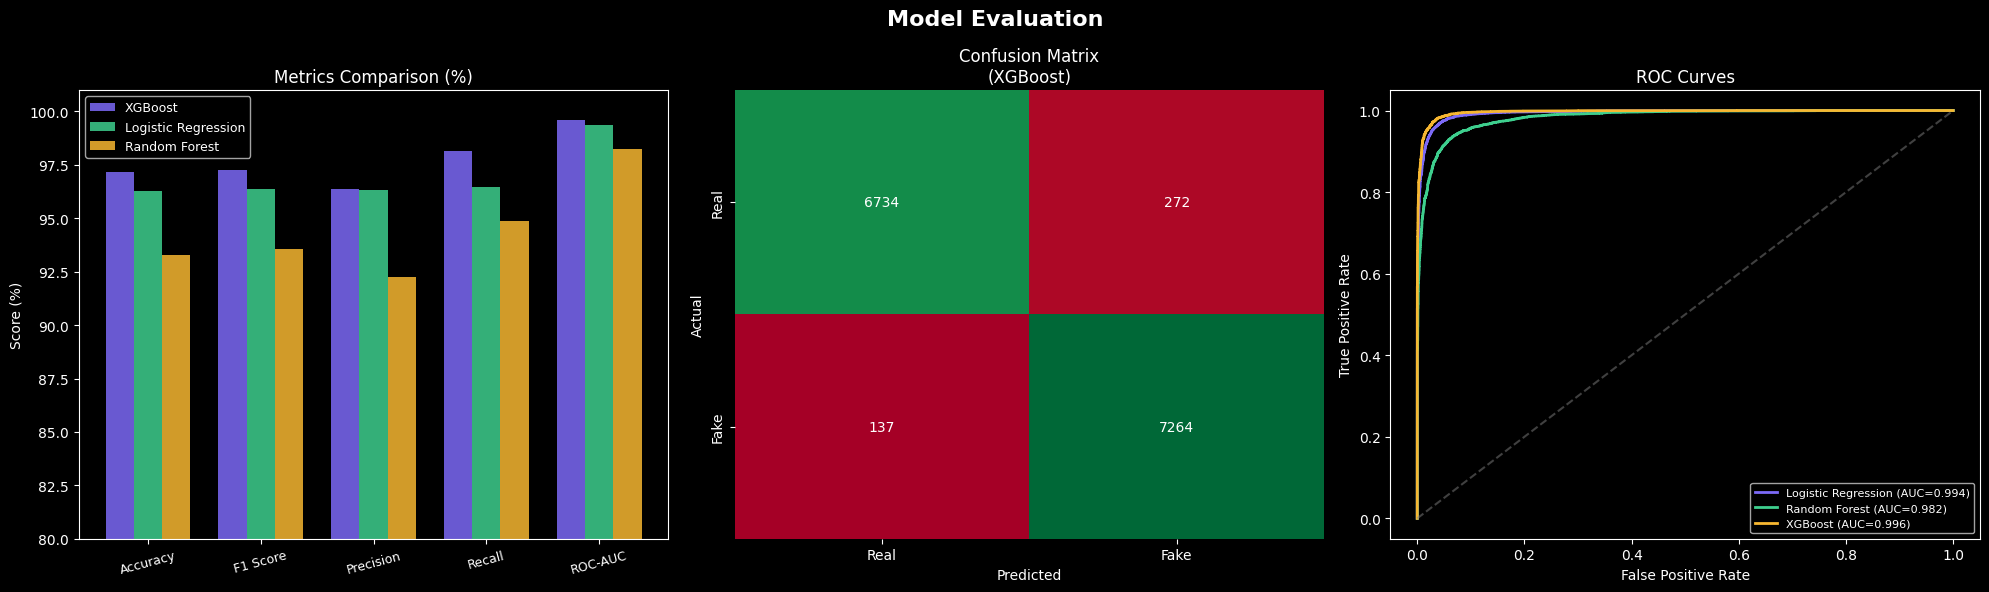

Chart saved → models/model_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# 1. Metrics comparison bar chart
metrics_to_plot = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_list = ['#7c6af7', '#3ecf8e', '#f7b731']

for i, row in results_df.iterrows():
    offset = (list(results_df.index).index(i)) * width
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + offset, vals, width, label=row['Model'],
                color=colors_list[list(results_df.index).index(i) % 3], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=15, fontsize=9)
axes[0].set_ylim(80, 101)
axes[0].set_title('Metrics Comparison (%)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Score (%)')

# 2. Confusion matrix for best model
best_model_name = results_df.iloc[0]['Model']
best_preds = trained_models[best_model_name]['preds']
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            ax=axes[1], cbar=False)
axes[1].set_title(f'Confusion Matrix\n({best_model_name})', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. ROC Curves
for i, (name, data) in enumerate(trained_models.items()):
    fpr, tpr, _ = roc_curve(y_test, data['probs'])
    auc = roc_auc_score(y_test, data['probs'])
    axes[2].plot(fpr, tpr, color=colors_list[i % 3],
                 label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[2].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[2].set_title('ROC Curves', fontsize=12)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → models/model_comparison.png')

## 7. Save Best Model

In [7]:
best_name = results_df.iloc[0]['Model']
best_model_obj = models[best_name]

with open(f'{MODELS_DIR}best_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model_obj, 'name': best_name}, f)

print(f'Best model: {best_name}')
print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]}%')
print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]}%')
print(f'  ROC-AUC:  {results_df.iloc[0]["ROC-AUC"]}%')
print(f'\nSaved → models/best_model.pkl')

print('\n' + '='*50)
print('NOTEBOOK 02 COMPLETE')
print('='*50)
print('Files saved:')
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(f'{MODELS_DIR}{f}')
    print(f'  {f}  ({size/1024:.1f} KB)')
print('\nNext step → Run Notebook 03: Unsupervised Clustering')

Best model: XGBoost
  F1 Score: 97.26%
  Accuracy: 97.16%
  ROC-AUC:  99.62%

Saved → models/best_model.pkl

NOTEBOOK 02 COMPLETE
Files saved:
  best_model.pkl  (776.5 KB)
  eda_overview.png  (89.1 KB)
  logistic_regression.pkl  (391.3 KB)
  model_comparison.png  (126.7 KB)
  model_results.json  (0.5 KB)
  random_forest.pkl  (34799.1 KB)
  tfidf_vectorizer.pkl  (1945.5 KB)
  top_words.png  (74.1 KB)
  xgboost.pkl  (776.5 KB)

Next step → Run Notebook 03: Unsupervised Clustering
